In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_visa_dataset.csv")
df.head()

,CASE_STATUS,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days
0,0,1,1009,1,34,10,-0.278511,-0.251113,5
1,0,1,12013,1,24,23,-0.734014,-1.037296,5
2,0,1,10836,1,9,20,-0.685448,-0.960521,5
3,0,1,27577,1,25,24,-0.734281,-1.095813,5
4,0,1,42658,1,47,45,-0.554148,-0.682077,5


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200998 entries, 0 to 200997
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CASE_STATUS            200998 non-null  int64  
 1   VISA_CLASS             200998 non-null  int64  
 2   JOB_TITLE              200998 non-null  int64  
 3   FULL_TIME_POSITION     200998 non-null  int64  
 4   EMPLOYER_STATE         200998 non-null  int64  
 5   WORKSITE_STATE         200998 non-null  int64  
 6   WAGE_RATE_OF_PAY_FROM  200998 non-null  float64
 7   PREVAILING_WAGE        200998 non-null  float64
 8   processing_days        200998 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 13.8 MB


,CASE_STATUS,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days
count,200998.000000,200998.000000,200998.000000,200998.000000,200998.000000,200998.000000,2.009980e+05,2.009980e+05,200998.000000
mean,0.123588,0.984288,29951.999498,0.987985,26.165753,25.355392,-2.352945e-16,9.389156e-17,24.192599
std,0.471156,0.197327,16207.335090,0.108953,17.318792,17.247754,1.000002e+00,1.000002e+00,87.263070
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.448312e+00,-2.448071e+00,0.000000
25%,0.000000,1.000000,15359.000000,1.000000,5.000000,6.000000,-3.802457e-01,-5.180546e-01,7.000000
50%,0.000000,1.000000,31746.000000,1.000000,26.000000,24.000000,-6.072385e-02,-4.843897e-02,7.000000
75%,0.000000,1.000000,43868.000000,1.000000,41.000000,42.000000,3.435935e-01,5.638018e-01,8.000000
max,3.000000,3.000000,56681.000000,1.000000,55.000000,54.000000,2.465288e+02,1.791582e+01,888.000000


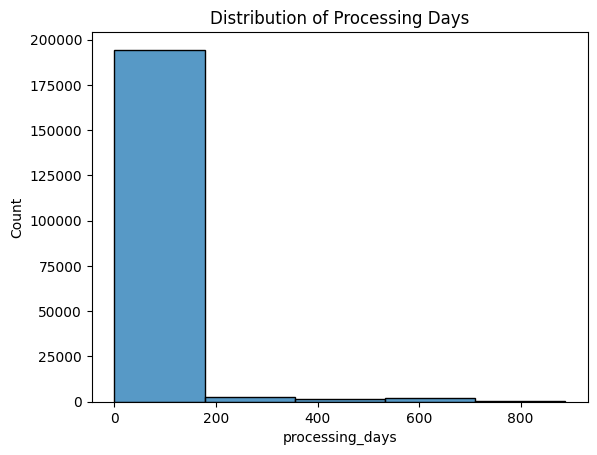

In [3]:
plt.figure()
sns.histplot(df['processing_days'], bins=5)

plt.title("Distribution of Processing Days")
plt.show()

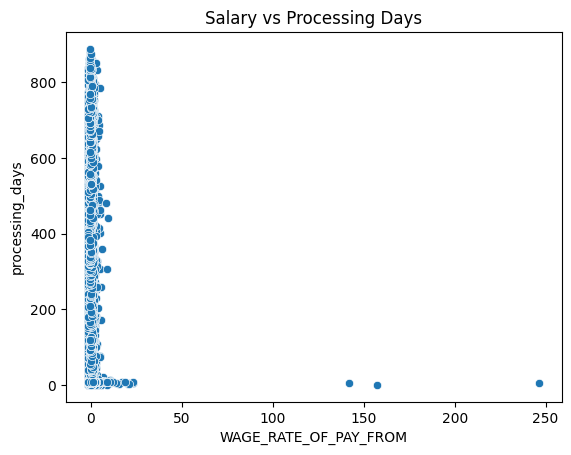

In [4]:
plt.figure()
sns.scatterplot(x='WAGE_RATE_OF_PAY_FROM', y='processing_days', data=df)

plt.title("Salary vs Processing Days")
plt.show()

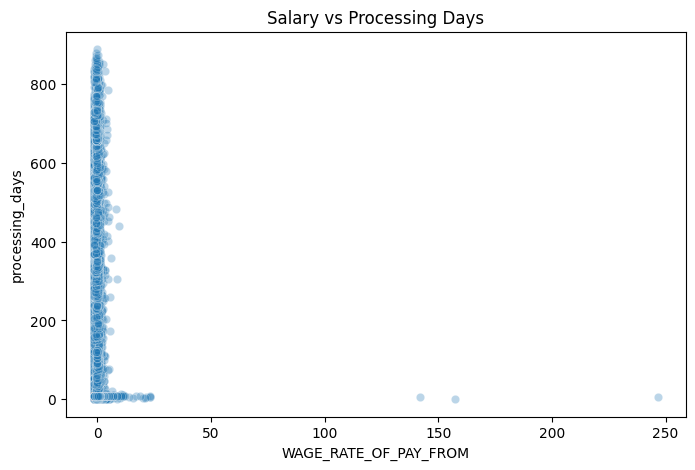

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='WAGE_RATE_OF_PAY_FROM',
    y='processing_days',
    data=df,
    alpha=0.3
)

plt.title("Salary vs Processing Days")
plt.show()

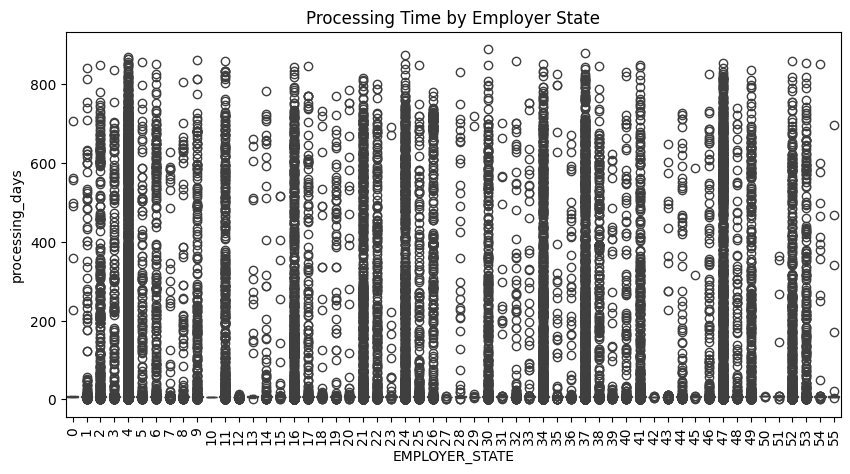

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x='EMPLOYER_STATE', y='processing_days', data=df)

plt.xticks(rotation=90)

plt.title("Processing Time by Employer State")

plt.show()

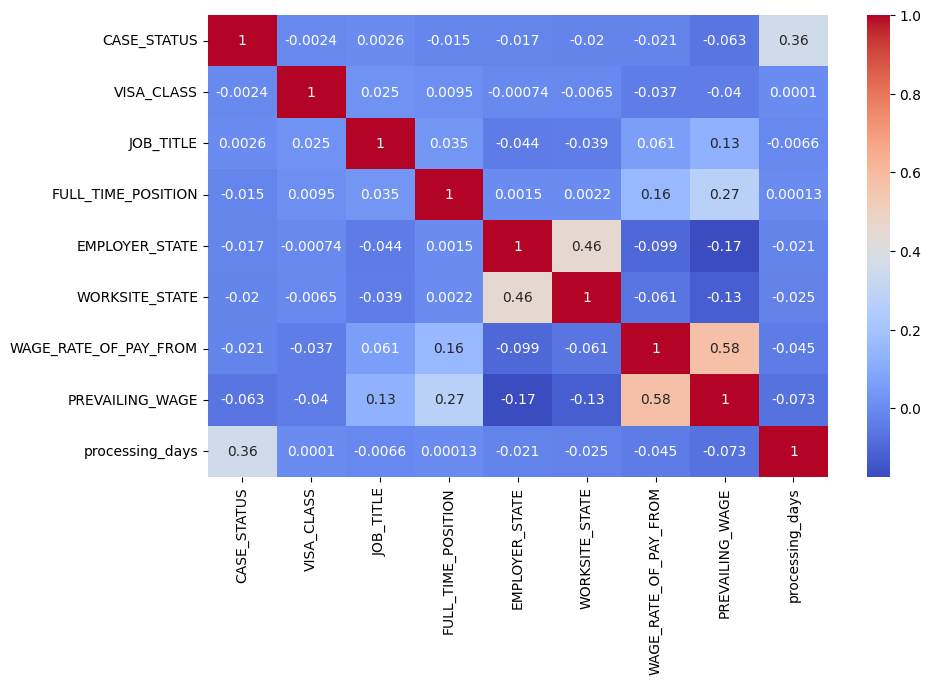

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6)) 
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
print("The correlation heatmap shows that most features have weak individual correlation with processing_days.\nThe strongest relationship is between CASE_STATUS and processing_days (0.36). \nAdditionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.")

The correlation heatmap shows that most features have weak individual correlation with processing_days.
The strongest relationship is between CASE_STATUS and processing_days (0.36). 
Additionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.


In [9]:
df['wage_ratio'] = df['WAGE_RATE_OF_PAY_FROM'] / df['PREVAILING_WAGE']

In [10]:
df.head()

,CASE_STATUS,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio
0,0,1,1009,1,34,10,-0.278511,-0.251113,5,1.109109
1,0,1,12013,1,24,23,-0.734014,-1.037296,5,0.707622
2,0,1,10836,1,9,20,-0.685448,-0.960521,5,0.713621
3,0,1,27577,1,25,24,-0.734281,-1.095813,5,0.670079
4,0,1,42658,1,47,45,-0.554148,-0.682077,5,0.812441


In [11]:
df_dates = pd.read_csv("dataset.csv", low_memory=False)

df['application_month'] = pd.to_datetime(df_dates['RECEIVED_DATE']).dt.month

In [12]:
state_avg = df.groupby('EMPLOYER_STATE')['processing_days'].transform('mean')

df['state_processing_avg'] = state_avg

In [13]:
df.head()

,CASE_STATUS,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg
0,0,1,1009,1,34,10,-0.278511,-0.251113,5,1.109109,9,16.459202
1,0,1,12013,1,24,23,-0.734014,-1.037296,5,0.707622,9,40.323003
2,0,1,10836,1,9,20,-0.685448,-0.960521,5,0.713621,9,19.781505
3,0,1,27577,1,25,24,-0.734281,-1.095813,5,0.670079,9,23.065644
4,0,1,42658,1,47,45,-0.554148,-0.682077,5,0.812441,9,23.650974


In [14]:
df['worksite_processing_avg'] = df.groupby('WORKSITE_STATE')['processing_days'].transform('mean')

df[['processing_days',
    'wage_ratio',
    'application_month',
    'state_processing_avg',
    'worksite_processing_avg']].corr()

,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
processing_days,1.000000,0.004283,-0.058298,0.111442,0.084787
wage_ratio,0.004283,1.000000,0.000630,0.002116,0.003274
application_month,-0.058298,0.000630,1.000000,-0.016047,-0.003092
state_processing_avg,0.111442,0.002116,-0.016047,1.000000,0.431232
worksite_processing_avg,0.084787,0.003274,-0.003092,0.431232,1.000000


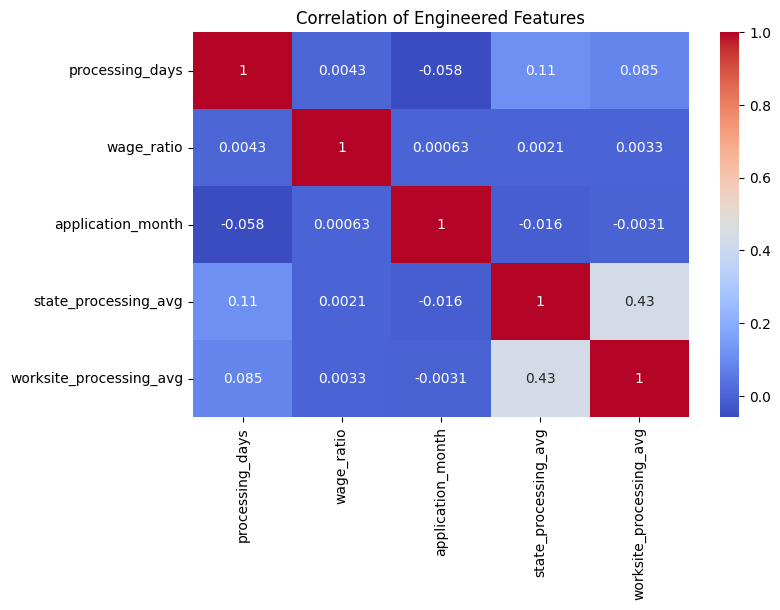

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['processing_days',
        'wage_ratio',
        'application_month',
        'state_processing_avg',
        'worksite_processing_avg']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")
plt.show()

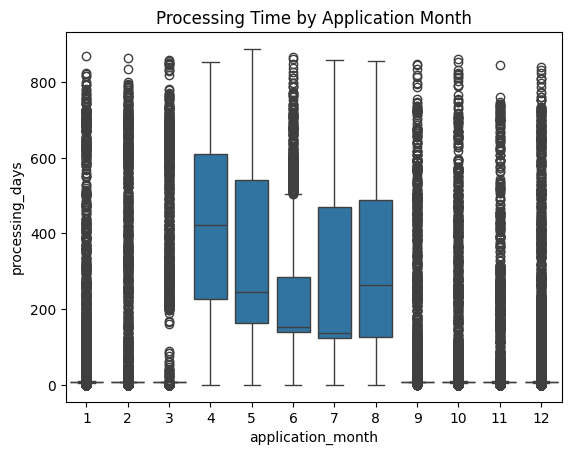

In [16]:
sns.boxplot(x='application_month', y='processing_days', data=df)

plt.title("Processing Time by Application Month")
plt.show()

In [17]:
print("The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) \nshow stronger correlation with processing time compared to wage-based features. \nThis suggests that geographic factors may influence visa processing duration more than salary-related attributes.")

The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) 
show stronger correlation with processing time compared to wage-based features. 
This suggests that geographic factors may influence visa processing duration more than salary-related attributes.


In [18]:
df.to_csv("cleaned_visa_feature_engineered_dataset.csv", index=False)
print("Milestone 2 Completed")

Milestone 2 Completed
